In [ ]:
# =====================================
# Step 1: Import Libraries
# =====================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [ ]:
# =====================================
# Step 2: Load Dataset
# =====================================
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")


In [ ]:
# =====================================
# Step 3: Basic Data Exploration
# =====================================
print(data_df.head())      # first few rows
print(data_df.info())      # dataset info
print(data_df.describe())      # statistical summary


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [ ]:
# =====================================
# Step 4: Missing Values
# =====================================
print(data_df.isnull().sum())


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# =====================================
# Step 5: Class Distribution
# =====================================
print(data_df["DEATH_EVENT"].value_counts())


DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


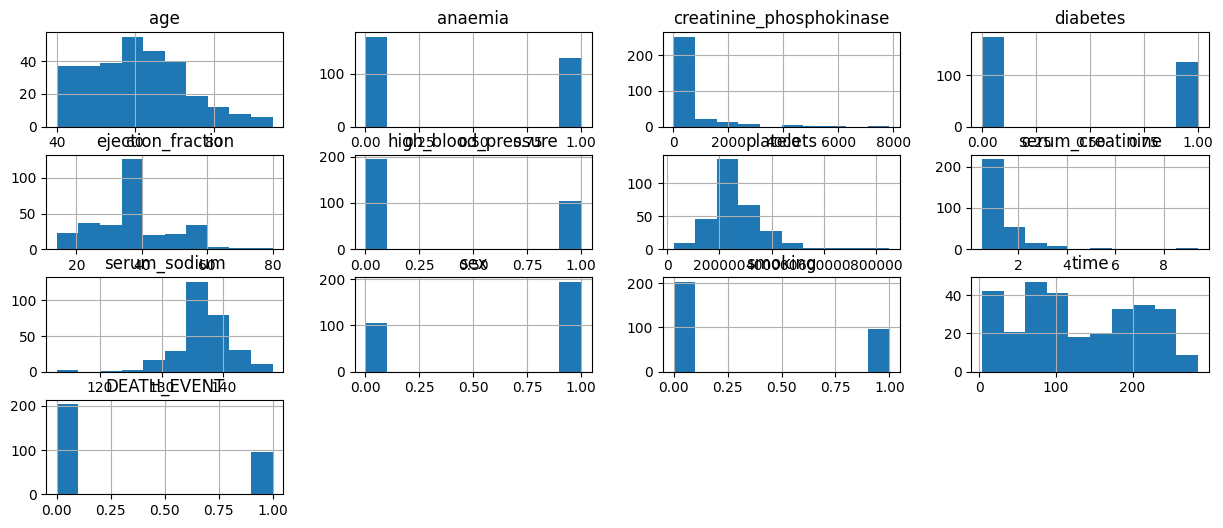

In [ ]:
# =====================================
# Step 6: Histogram Plot
# =====================================
data_df.hist(figsize=(15,6))
plt.show()


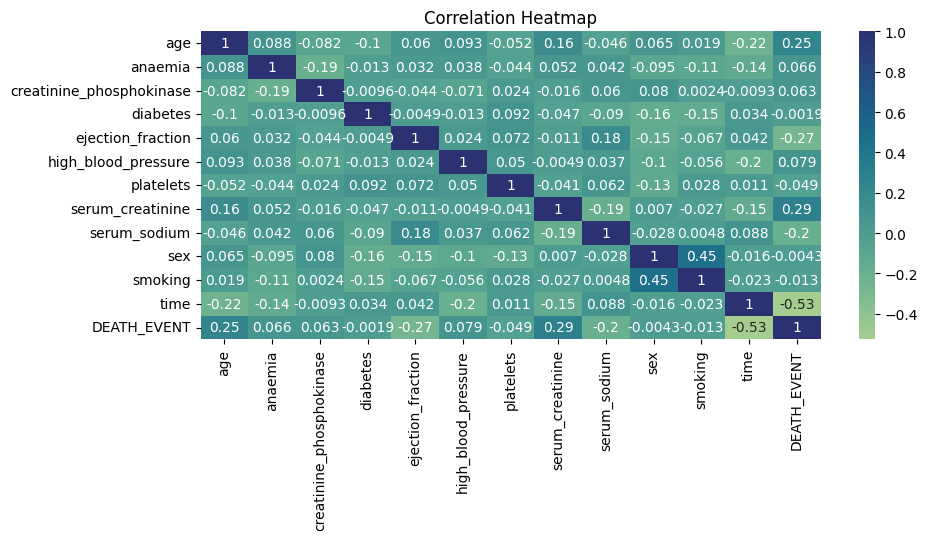

In [ ]:
# =====================================
# Step 7: Correlation Heatmap
# =====================================
plt.figure(figsize=(10,4))

sns.heatmap(
    data_df.corr(),
    annot=True,
    cmap="crest"
)

plt.title("Correlation Heatmap")
plt.show()

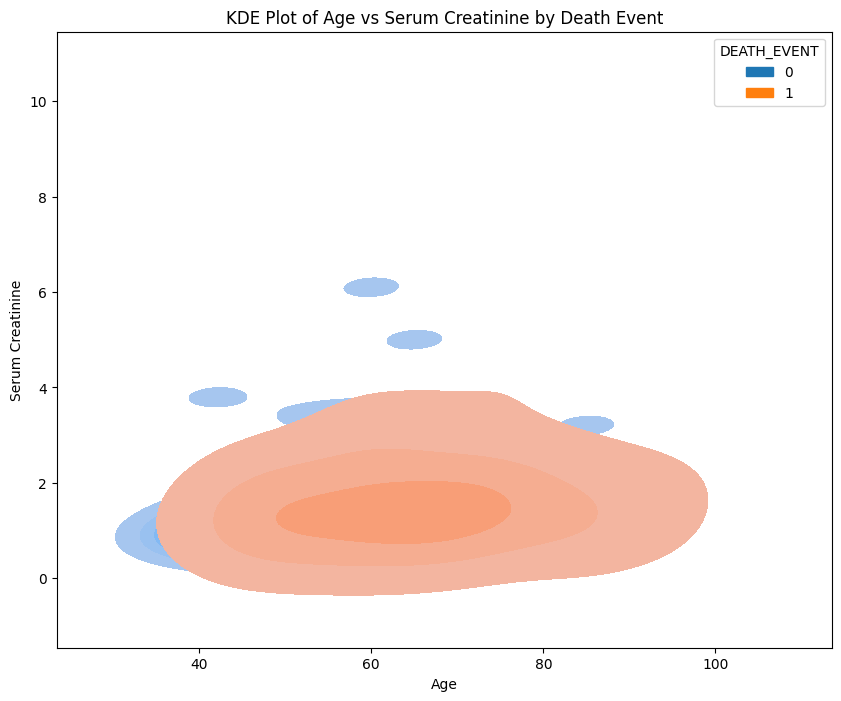

In [ ]:
# =====================================
# Step 8: KDE Plot
# =====================================
plt.figure(figsize=(10,8))

sns.kdeplot(
    x = data_df["age"],
    y = data_df["serum_creatinine"],
    hue = data_df["DEATH_EVENT"],
    fill = True
)

plt.title("KDE Plot of Age vs Serum Creatinine by Death Event")
plt.xlabel("Age")
plt.ylabel("Serum Creatinine")

plt.show()


In [ ]:
# =====================================
# Step 9: Feature & Target Split
# =====================================
X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]


In [ ]:
# =====================================
# Step 10: Train-Test Split
# =====================================
X_train, X_test, y_train, y_test =train_test_split(
    X, y, test_size=2, random_state=2
)


In [ ]:
# =====================================
# Step 11: Feature Scaling
# =====================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# =====================================
# Step 12: Train SVM Model
# =====================================
model = SVC(kernel="linear")
model.fit(X_train, y_train)


SVC(kernel='linear')

In [ ]:
# =====================================
# Step 13: Prediction & Evaluation
# =====================================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [ ]:
# =====================================
# Step 14: ANN Model
# =====================================

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import callbacks

early_stopping =callbacks.EarlyStopping(
    min_delta=0.001,
    patience=20,
    restore_best_weights=True
)

ann = Sequential()

ann.add(Dense(units=16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(units=8, activation='relu'))
ann.add(Dropout(0.2))
ann.add(Dense(units=4, activation='relu'))
ann.add(Dropout(0.2))

# Output Layer
ann.add(Dense(units=1, activation='sigmoid'))

# Compile
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = ann.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping]
)




Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3544 - loss: 0.7574 - val_accuracy: 0.3833 - val_loss: 0.7128
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3249 - loss: 0.7481 - val_accuracy: 0.4167 - val_loss: 0.7025
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3544 - loss: 0.7227 - val_accuracy: 0.4500 - val_loss: 0.6953
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4008 - loss: 0.7187 - val_accuracy: 0.4333 - val_loss: 0.6898
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5063 - loss: 0.6994 - val_accuracy: 0.5167 - val_loss: 0.6863
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5232 - loss: 0.6955 - val_accuracy: 0.5833 - val_loss: 0.6839
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5992 - loss: 0.6922 - val_accuracy: 0.5833 - val_loss: 0.6821
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6287 - loss: 0.6866 - val_accuracy: 0.5833 - val_loss: 0.6802
Epoc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
ANN Accuracy: 1.0


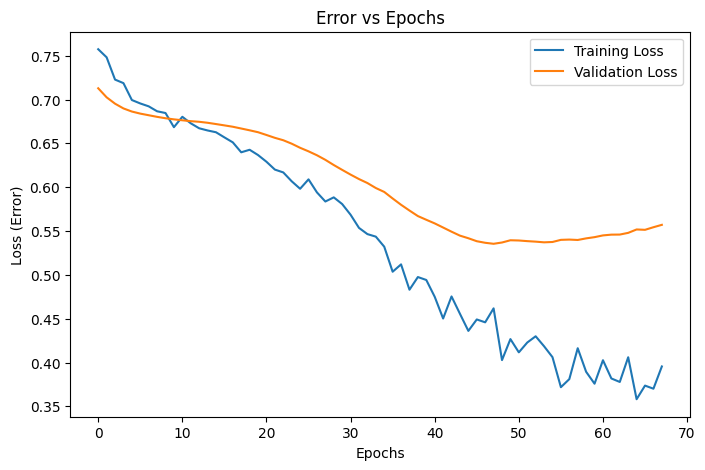

In [ ]:
# =====================================
# Step 15: ANN Prediction & Evaluation
# =====================================
y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))


plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Error vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Error)')
plt.legend()

plt.show()
